# Exposure Fusion - implementazione guidata

Questo notebook implementa passo per passo l'algoritmo **Exposure Fusion** sul caso di studio `venice_carnival`.

La scelta di questo dataset e intenzionale: tra i dati disponibili e l'esempio piu utile per confrontare l'andamento delle mappe dei pesi, perche sono presenti anche le immagini delle mappe fornite nel materiale del paper (`image1_mapped.jpg`, `image2_mapped.jpg`, `image3_mapped.jpg`). In questo modo possiamo controllare visivamente se le nostre mappe stanno andando nella stessa direzione.

## Carichiamo le immagini LDR

Partiamo dalle tre esposizioni LDR della scena Venice Carnival. Le immagini vengono convertite in RGB e normalizzate nell'intervallo $[0, 1]$.

Shape immagini: [(800, 1200, 3), (800, 1200, 3), (800, 1200, 3)]


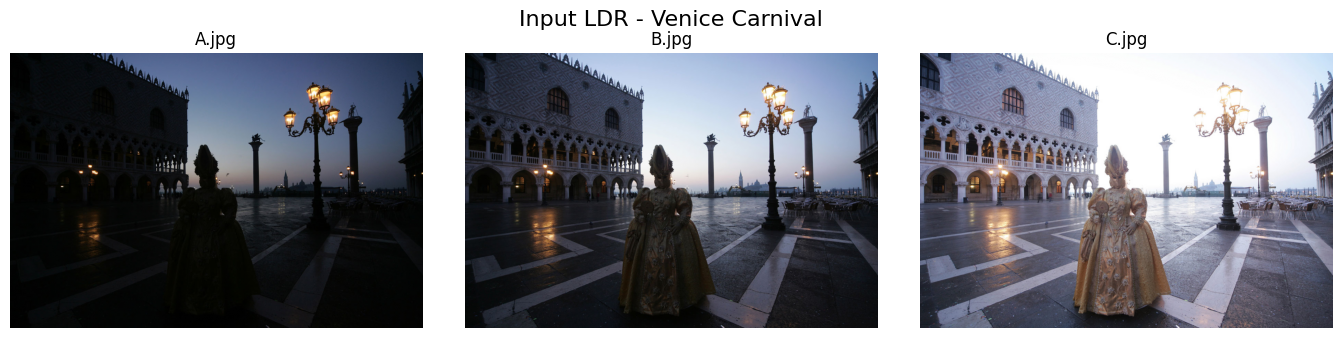

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import convolve
from skimage import img_as_float
from skimage.color import rgb2gray
from skimage.transform import pyramid_expand, pyramid_gaussian

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["image.cmap"] = "gray"

input_paths = [
    Path("images/venice_carnival/A.jpg"),
    Path("images/venice_carnival/B.jpg"),
    Path("images/venice_carnival/C.jpg"),
]

paper_weight_paths = [
    Path("images/venice_carnival/image1_mapped.jpg"),
    Path("images/venice_carnival/image2_mapped.jpg"),
    Path("images/venice_carnival/image3_mapped.jpg"),
]

reference_path = Path("images/venice_carnival/result.jpg")


def load_rgb_float(path: str | Path) -> np.ndarray:
    return img_as_float(np.array(Image.open(path).convert("RGB")))


def show_images(images, titles=None, *, cols=None, suptitle=None, cmap=None):
    if titles is None:
        titles = [""] * len(images)
    if cols is None:
        cols = len(images)
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 3.4 * rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, image, title in zip(axes.ravel(), images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap or "gray")
        else:
            ax.imshow(np.clip(image, 0, 1))
        ax.set_title(title)
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()

images = [load_rgb_float(path) for path in input_paths]
reference = load_rgb_float(reference_path)

print("Shape immagini:", [image.shape for image in images])
show_images(images, [path.name for path in input_paths], suptitle="Input LDR - Venice Carnival")

## Calcoliamo le misure di qualita

Per ogni immagine calcoliamo le tre misure usate da Exposure Fusion. Nel paper il peso di un pixel e definito come:

$$
W_{i,j,k} = C_{i,j,k}^{\omega_C} S_{i,j,k}^{\omega_S} E_{i,j,k}^{\omega_E}
$$

Dove $(i,j)$ indica il pixel e $k$ indica l'immagine della sequenza.

### Contrasto

Il contrasto premia bordi e dettagli locali. Nel paper viene calcolato come valore assoluto della risposta di un filtro Laplaciano applicato alla luminanza/grayscale:

$$
C_{i,j,k} = |L(I_k)_{i,j}|
$$

Nel nostro caso $L$ e il Laplaciano discreto a 4-neighbor:

$$
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

### Saturazione

La saturazione premia pixel con canali RGB piu differenziati. Per ogni pixel calcoliamo la deviazione standard sui canali:

$$
S_{i,j,k} = \operatorname{std}(R_{i,j,k}, G_{i,j,k}, B_{i,j,k})
$$

### Well-exposedness

La well-exposedness premia intensita intermedie e penalizza valori troppo vicini a 0 o 1. Per ogni canale $c$:

$$
E_c(I_{i,j,k}) = \exp\left(-\frac{(I_{i,j,k,c} - 0.5)^2}{2\sigma^2}\right)
$$

Il valore finale del pixel e il prodotto sui tre canali:

$$
E_{i,j,k} = \prod_{c \in \{R,G,B\}} E_c(I_{i,j,k})
$$

In questa implementazione uso i parametri di default:

- $\omega_C = 1$
- $\omega_S = 1$
- $\omega_E = 1$
- $\sigma = 0.2$ per la well-exposedness

In [2]:
# Kernel Laplaciano a 4-neighbor usato per stimare il contrasto locale.
LAPLACIAN_KERNEL = np.array(
    [
        [0.0, 1.0, 0.0],
        [1.0, -4.0, 1.0],
        [0.0, 1.0, 0.0],
    ]
)


def contrast_measure(image: np.ndarray) -> np.ndarray:
    gray = rgb2gray(image)
    return np.abs(convolve(gray, LAPLACIAN_KERNEL, mode="reflect"))


def saturation_measure(image: np.ndarray) -> np.ndarray:
    return np.std(image, axis=2)


def exposedness_curve(values: np.ndarray, sigma: float = 0.2) -> np.ndarray:
    return np.exp(-((values - 0.5) ** 2) / (2 * sigma**2))


def well_exposedness_measure(image: np.ndarray, sigma: float = 0.2) -> np.ndarray:
    return np.prod(exposedness_curve(image, sigma=sigma), axis=2)


def quality_measures(image: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return (
        contrast_measure(image),
        saturation_measure(image),
        well_exposedness_measure(image),
    )

### Esempio delle misure su una singola immagine

Visualizziamo contrasto, saturazione e well-exposedness sulla seconda esposizione. Questa immagine e un buon esempio perche contiene sia dettagli sul soggetto sia zone molto luminose sullo sfondo.

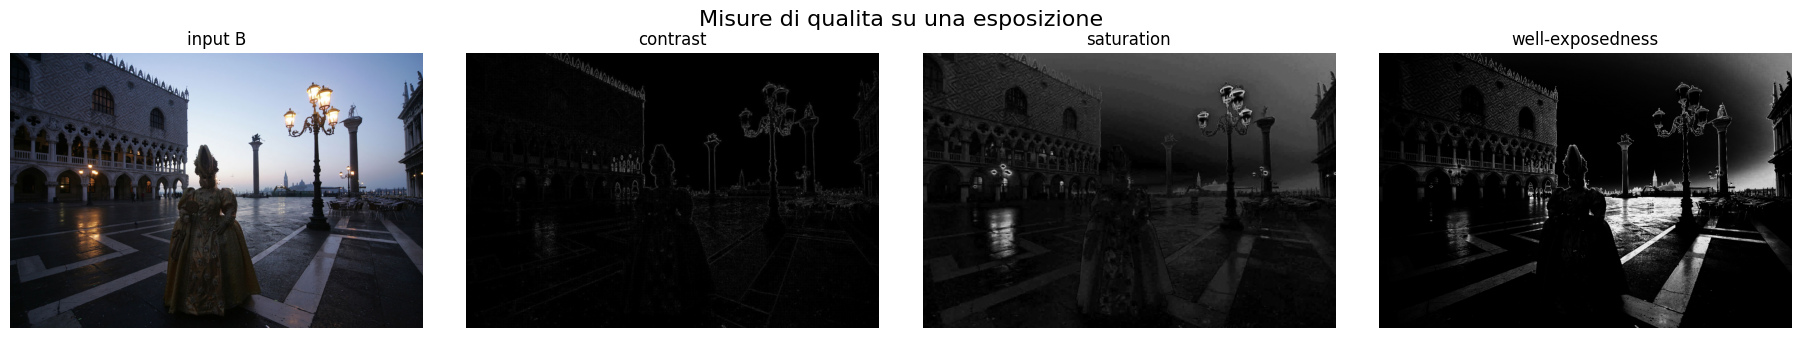

In [3]:
example_image = images[1]
contrast, saturation, exposedness = quality_measures(example_image)

show_images(
    [example_image, contrast, saturation, exposedness],
    ["input B", "contrast", "saturation", "well-exposedness"],
    suptitle="Misure di qualita su una esposizione",
)

## Calcoliamo le mappe dei pesi

Ora combiniamo le tre misure per prodotto. Le mappe ottenute sono ancora pesi grezzi: sono utili per capire dove ogni immagine e forte, ma devono essere normalizzate prima della fusione.

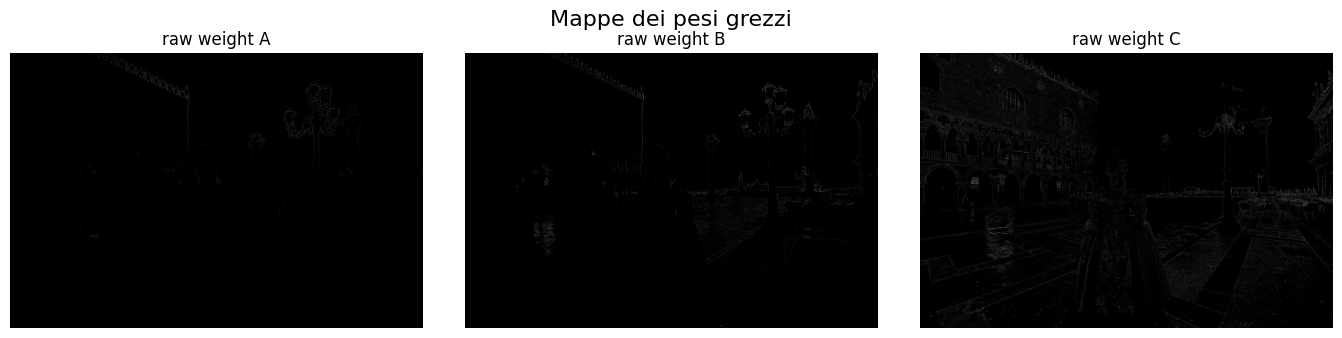

In [4]:
def weight_map(
    image: np.ndarray,
    *,
    omega_contrast: float = 1.0,
    omega_saturation: float = 1.0,
    omega_exposedness: float = 1.0,
) -> np.ndarray:
    contrast, saturation, exposedness = quality_measures(image)
    return (
        contrast**omega_contrast
        * saturation**omega_saturation
        * exposedness**omega_exposedness
    )

raw_weights = np.stack([weight_map(image) for image in images])

show_images(
    list(raw_weights),
    ["raw weight A", "raw weight B", "raw weight C"],
    suptitle="Mappe dei pesi grezzi",
)

## Normalizziamo i pesi

Le mappe appena calcolate sono pesi grezzi: indicano quanto ciascun pixel di ciascuna esposizione e buono, ma non sono ancora confrontabili come coefficienti di fusione.

Per ogni pixel $(i,j)$ normalizziamo i pesi lungo la sequenza di immagini:

$$
\hat{W}_{i,j,k} = \frac{W_{i,j,k}}{\sum_n W_{i,j,n}}
$$

Dopo la normalizzazione, la somma dei contributi delle tre esposizioni deve essere pari a 1:

$$
\sum_k \hat{W}_{i,j,k} = 1
$$

Questo e importante perche i pesi normalizzati diventano coefficienti di combinazione: se una esposizione ha peso alto in una regione, le altre esposizioni devono contribuire meno alla stessa regione.

Nel codice aggiungo anche un caso di sicurezza: se per un pixel la somma dei pesi grezzi e nulla o quasi nulla, assegno un peso uniforme $1/N$ a tutte le immagini. In questo modo evito divisioni per zero e mantengo la fusione ben definita anche nei casi degenerati.

Errore massimo sulla somma dei pesi normalizzati: 3.331e-16


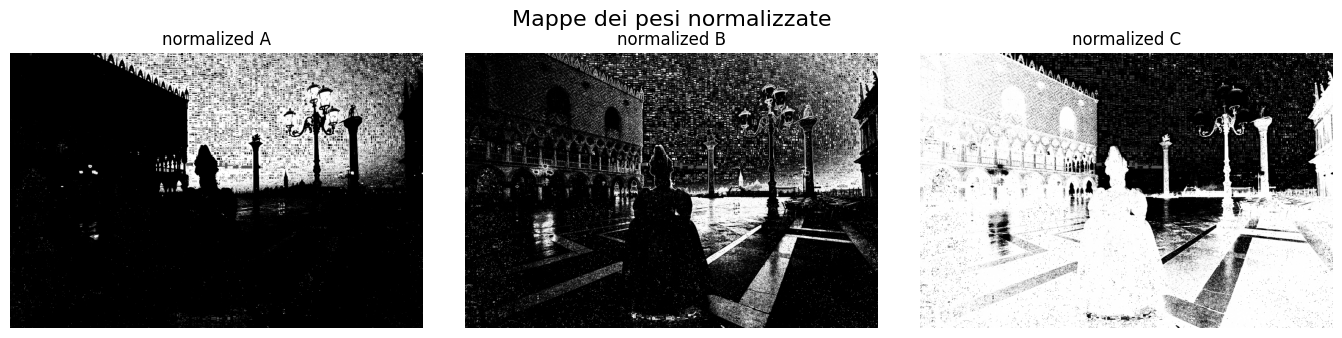

In [5]:
def normalize_weights(weights: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    weight_sum = weights.sum(axis=0, keepdims=True)
    uniform = np.full_like(weights, 1.0 / weights.shape[0])
    return np.divide(weights, weight_sum, out=uniform, where=weight_sum > eps)

normalized_weights = normalize_weights(raw_weights)
weight_sum_error = np.abs(normalized_weights.sum(axis=0) - 1).max()

print(f"Errore massimo sulla somma dei pesi normalizzati: {weight_sum_error:.3e}")
show_images(
    list(normalized_weights),
    ["normalized A", "normalized B", "normalized C"],
    suptitle="Mappe dei pesi normalizzate",
)

## Confronto con le mappe dei pesi del paper

Per Venice Carnival abbiamo anche le mappe dei pesi presenti nel materiale del paper. Non mi aspetto una uguaglianza pixel-perfect, perche possono cambiare dettagli implementativi, normalizzazioni e visualizzazione. Il confronto serve per capire se qualitativamente le regioni favorite sono coerenti.

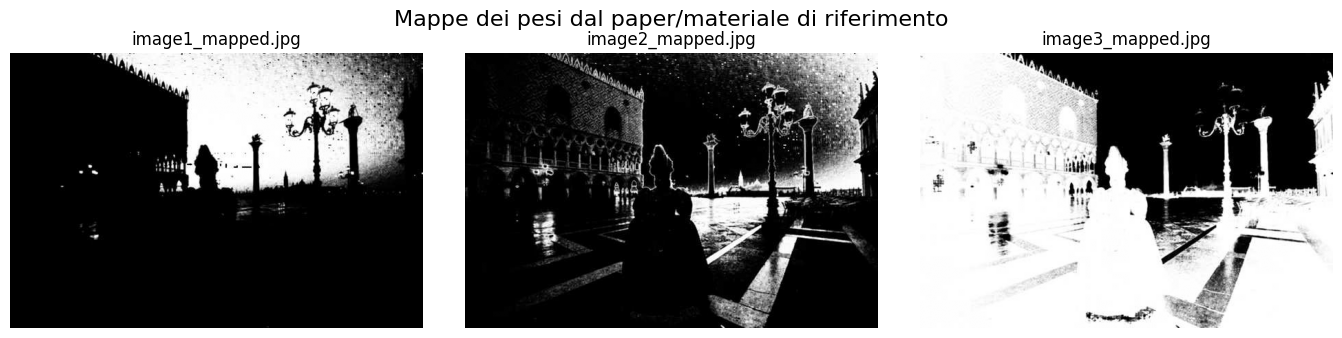

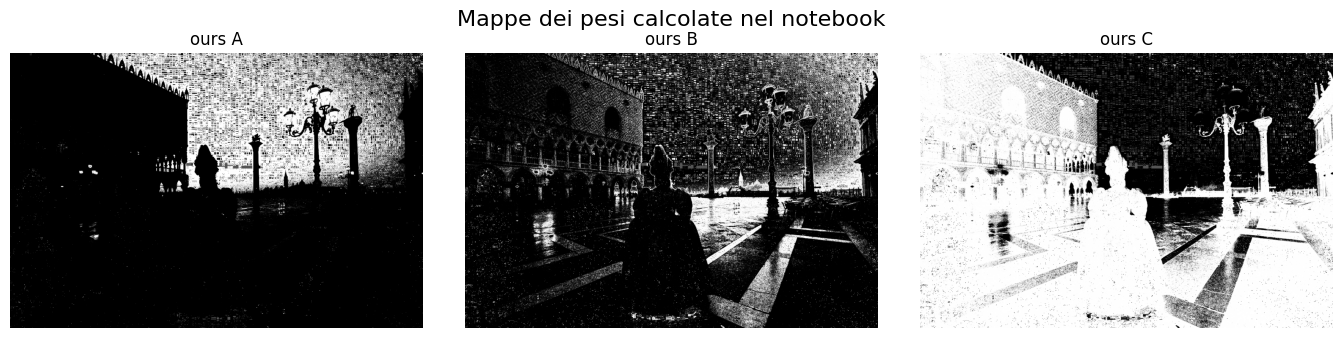

In [6]:
paper_weight_images = [load_rgb_float(path) for path in paper_weight_paths]

show_images(
    paper_weight_images,
    [path.name for path in paper_weight_paths],
    suptitle="Mappe dei pesi dal paper/materiale di riferimento",
)

show_images(
    list(normalized_weights),
    ["ours A", "ours B", "ours C"],
    suptitle="Mappe dei pesi calcolate nel notebook",
)

## Risultato parziale: fusione lineare dei pixel

Prima della fusione multirisoluzione, calcoliamo una fusione diretta:

$$
R = \sum_k \hat{W}_k I_k
$$

Questa versione e utile come controllo intermedio, ma puo produrre transizioni piu visibili perche combina direttamente immagini con esposizioni diverse.

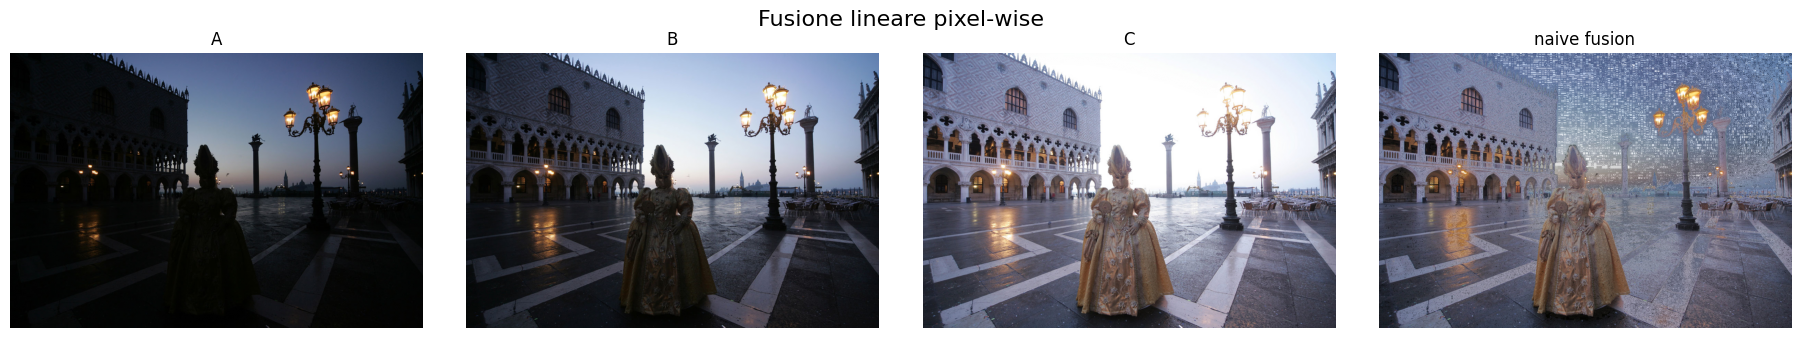

In [7]:
def naive_fusion(images: list[np.ndarray], weights: np.ndarray) -> np.ndarray:
    fused = np.zeros_like(images[0])
    for image, weight in zip(images, weights):
        fused += weight[..., np.newaxis] * image
    return np.clip(fused, 0.0, 1.0)

naive_result = naive_fusion(images, normalized_weights)

show_images(
    [images[0], images[1], images[2], naive_result],
    ["A", "B", "C", "naive fusion"],
    suptitle="Fusione lineare pixel-wise",
)

## Costruiamo le piramidi Gaussiane e Laplaciane

La fusione finale del paper non viene fatta direttamente sui pixel, ma sulle piramidi:

- immagini $I_k$ -> piramidi Laplaciane;
- pesi $\hat{W}_k$ -> piramidi Gaussiane.

Questo permette di fondere dettagli fini e transizioni larghe a scale diverse.

In [8]:
def build_gaussian_pyramid(
    image: np.ndarray,
    *,
    max_layer: int = -1,
    downscale: int = 2,
    channel_axis: int | None = None,
) -> list[np.ndarray]:
    return [
        np.asarray(level)
        for level in pyramid_gaussian(
            image,
            max_layer=max_layer,
            downscale=downscale,
            preserve_range=True,
            channel_axis=channel_axis,
        )
    ]


def crop_like(image: np.ndarray, reference_shape: tuple[int, ...]) -> np.ndarray:
    slices = tuple(slice(0, size) for size in reference_shape)
    return image[slices]


def build_laplacian_pyramid(
    image: np.ndarray,
    *,
    max_layer: int = -1,
    downscale: int = 2,
) -> list[np.ndarray]:
    gaussian_levels = build_gaussian_pyramid(
        image,
        max_layer=max_layer,
        downscale=downscale,
        channel_axis=-1,
    )
    laplacian_levels = []
    for level in range(len(gaussian_levels) - 1):
        expanded = pyramid_expand(
            gaussian_levels[level + 1],
            upscale=downscale,
            preserve_range=True,
            channel_axis=-1,
        )
        expanded = crop_like(expanded, gaussian_levels[level].shape)
        laplacian_levels.append(gaussian_levels[level] - expanded)
    laplacian_levels.append(gaussian_levels[-1])
    return laplacian_levels


def collapse_laplacian_pyramid(
    laplacian_levels: list[np.ndarray], *, downscale: int = 2) -> np.ndarray:
    image = laplacian_levels[-1]
    for level in reversed(laplacian_levels[:-1]):
        image = pyramid_expand(
            image,
            upscale=downscale,
            preserve_range=True,
            channel_axis=-1,
        )
        image = crop_like(image, level.shape)
        image = image + level
    return image

### Visualizziamo le piramidi

Mostro i primi livelli della piramide Gaussiana e Laplaciana di una esposizione. Per visualizzare i livelli Laplaciani, che possono avere valori negativi, li centro intorno a 0.5.

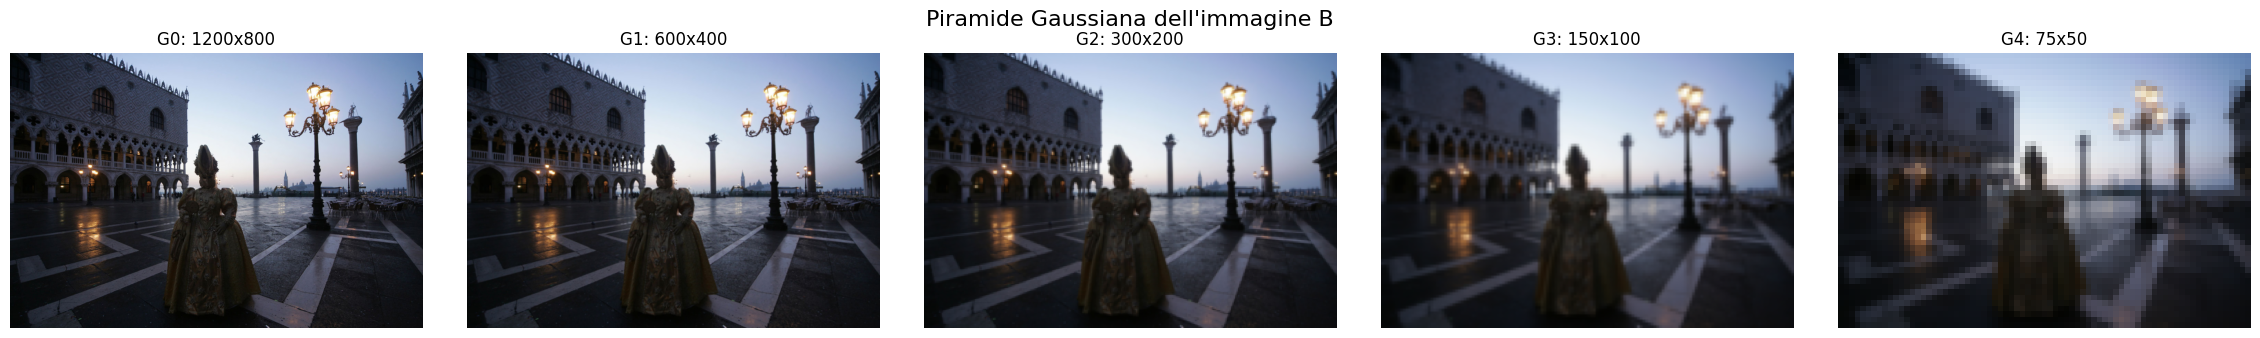

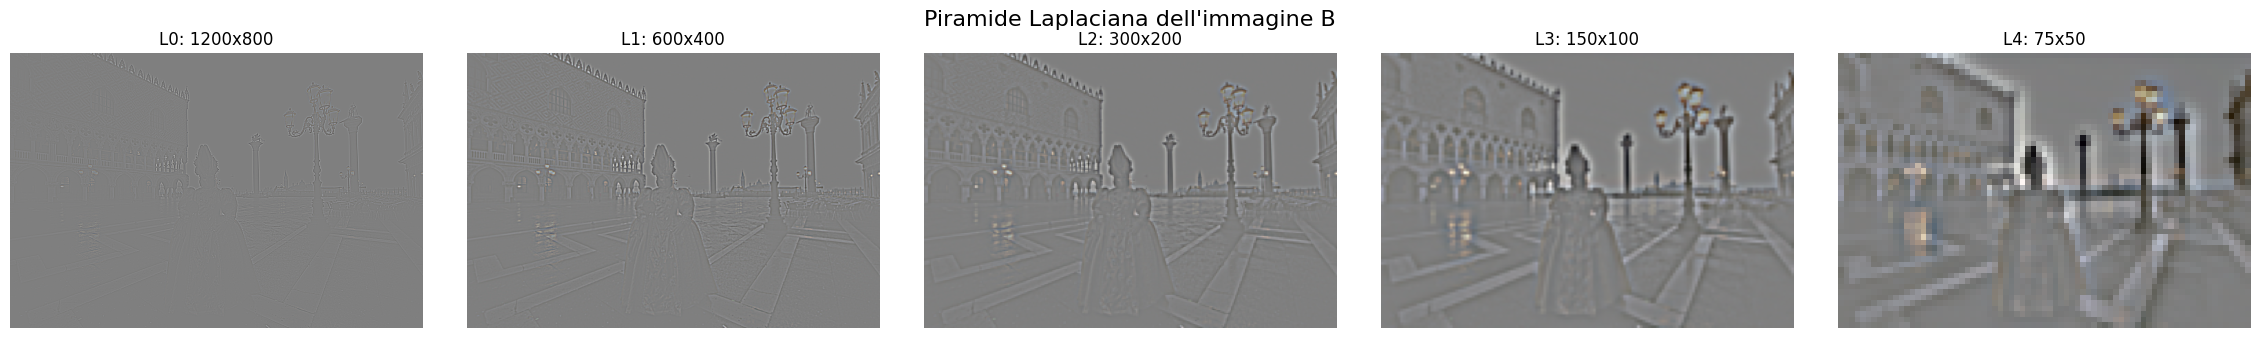

In [9]:
def laplacian_for_display(level: np.ndarray) -> np.ndarray:
    max_abs = np.max(np.abs(level))
    if max_abs <= 0:
        return np.full_like(level, 0.5)
    return np.clip(0.5 + level / (2 * max_abs), 0.0, 1.0)

gaussian_levels = build_gaussian_pyramid(images[1], max_layer=5, channel_axis=-1)
laplacian_levels = build_laplacian_pyramid(images[1], max_layer=5)

show_images(
    gaussian_levels[:5],
    [f"G{i}: {level.shape[1]}x{level.shape[0]}" for i, level in enumerate(gaussian_levels[:5])],
    suptitle="Piramide Gaussiana dell'immagine B",
)
show_images(
    [laplacian_for_display(level) for level in laplacian_levels[:5]],
    [f"L{i}: {level.shape[1]}x{level.shape[0]}" for i, level in enumerate(laplacian_levels[:5])],
    suptitle="Piramide Laplaciana dell'immagine B",
)

## Fusione multirisoluzione

Per ogni livello $l$ combino i livelli Laplaciani delle immagini con i livelli Gaussiani dei pesi:

$$
L_l(R) = \sum_k G_l(\hat{W}_k) L_l(I_k)
$$

Dopo la costruzione delle piramidi Gaussiane dei pesi, rinormalizzo i pesi a ogni livello. Questa e una scelta implementativa per evitare piccoli drift numerici dopo il downsampling.

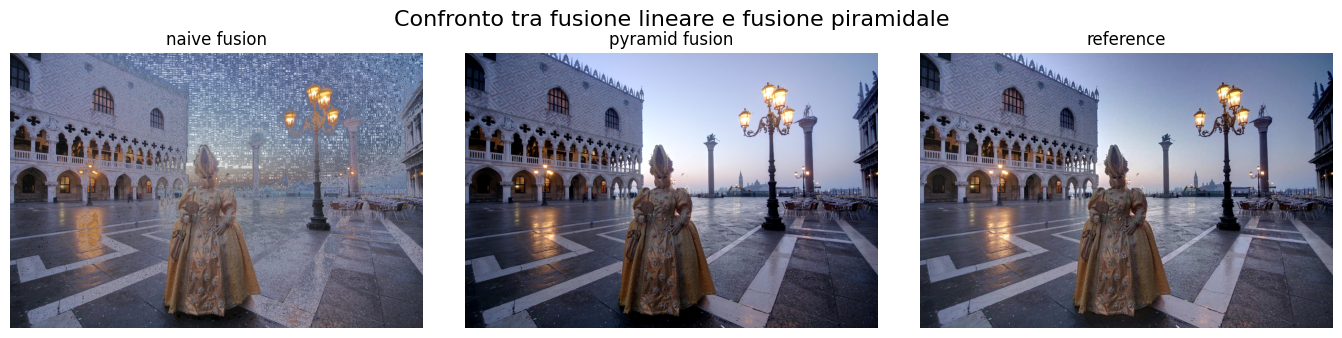

In [10]:
def exposure_fusion(images: list[np.ndarray]) -> dict[str, object]:
    raw_weights = np.stack([weight_map(image) for image in images])
    normalized_weights = normalize_weights(raw_weights)

    image_laplacian_pyramids = [build_laplacian_pyramid(image) for image in images]
    num_levels = len(image_laplacian_pyramids[0])

    weight_gaussian_pyramids = [
        build_gaussian_pyramid(weight, max_layer=num_levels - 1, channel_axis=None)
        for weight in normalized_weights
    ]

    # Rinormalizzazione dei pesi a ogni scala della piramide.
    for level in range(num_levels):
        level_weights = np.stack([pyramid[level] for pyramid in weight_gaussian_pyramids])
        normalized_level_weights = normalize_weights(level_weights)
        for image_index, pyramid in enumerate(weight_gaussian_pyramids):
            pyramid[level] = normalized_level_weights[image_index]

    fused_laplacian_pyramid = []
    for level in range(num_levels):
        fused_level = np.zeros_like(image_laplacian_pyramids[0][level])
        for image_index in range(len(images)):
            weights_at_level = weight_gaussian_pyramids[image_index][level][..., np.newaxis]
            fused_level += weights_at_level * image_laplacian_pyramids[image_index][level]
        fused_laplacian_pyramid.append(fused_level)

    fused_raw = collapse_laplacian_pyramid(fused_laplacian_pyramid)
    fused_image = np.clip(fused_raw, 0.0, 1.0)

    return {
        "raw_weights": raw_weights,
        "normalized_weights": normalized_weights,
        "weight_gaussian_pyramids": weight_gaussian_pyramids,
        "image_laplacian_pyramids": image_laplacian_pyramids,
        "fused_laplacian_pyramid": fused_laplacian_pyramid,
        "fused_raw": fused_raw,
        "fused_image": fused_image,
    }

result = exposure_fusion(images)
fused_image = result["fused_image"]

show_images(
    [naive_result, fused_image, reference],
    ["naive fusion", "pyramid fusion", "reference"],
    suptitle="Confronto tra fusione lineare e fusione piramidale",
)

## Controlli numerici

Aggiungo tre controlli semplici:

1. i pesi normalizzati devono sommare a 1;
2. anche i pesi nelle piramidi Gaussiane devono sommare a 1 per livello;
3. una piramide Laplaciana deve essere ricostruibile collassandola.

Questi controlli non dimostrano da soli la qualita visiva, ma verificano che i passaggi matematici principali siano coerenti.

In [11]:
def reconstruction_error(image: np.ndarray) -> float:
    pyramid = build_laplacian_pyramid(image)
    reconstructed = collapse_laplacian_pyramid(pyramid)
    return float(np.max(np.abs(reconstructed - image)))

initial_weight_error = float(np.max(np.abs(result["normalized_weights"].sum(axis=0) - 1.0)))
level_weight_errors = []
for level in range(len(result["weight_gaussian_pyramids"][0])):
    level_sum = sum(pyramid[level] for pyramid in result["weight_gaussian_pyramids"])
    level_weight_errors.append(float(np.max(np.abs(level_sum - 1.0))))

print(f"Errore pesi iniziali: {initial_weight_error:.3e}")
print(f"Errore massimo pesi piramidali: {max(level_weight_errors):.3e}")
print(f"Errore ricostruzione piramide Laplaciana: {reconstruction_error(images[0]):.3e}")
print(f"Numero livelli piramidali: {len(result['fused_laplacian_pyramid'])}")

Errore pesi iniziali: 3.331e-16
Errore massimo pesi piramidali: 2.220e-16


Errore ricostruzione piramide Laplaciana: 2.220e-16
Numero livelli piramidali: 12


## Risultato finale

Mostro il risultato finale insieme al riferimento disponibile e a una mappa di differenza assoluta. La differenza non e una metrica percettiva completa, ma aiuta a localizzare le regioni dove il risultato diverge maggiormente dal riferimento.

MAE vs reference: 0.092841
MSE vs reference: 0.011839


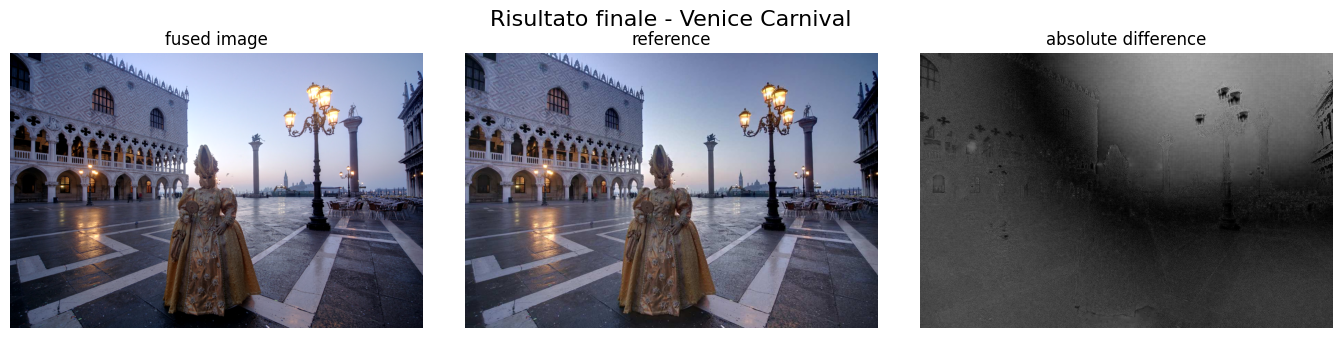

In [12]:
def absolute_difference_map(image: np.ndarray, reference: np.ndarray) -> np.ndarray:
    return np.abs(image - reference).mean(axis=2)


def normalized_for_display(image: np.ndarray) -> np.ndarray:
    minimum = image.min()
    maximum = image.max()
    if maximum <= minimum:
        return np.zeros_like(image)
    return (image - minimum) / (maximum - minimum)

difference = normalized_for_display(absolute_difference_map(fused_image, reference))
mae = float(np.abs(fused_image - reference).mean())
mse = float(np.mean((fused_image - reference) ** 2))

print(f"MAE vs reference: {mae:.6f}")
print(f"MSE vs reference: {mse:.6f}")

show_images(
    [fused_image, reference, difference],
    ["fused image", "reference", "absolute difference"],
    suptitle="Risultato finale - Venice Carnival",
)

## Nota finale

L'implementazione ricostruisce il nucleo dell'algoritmo: calcolo delle mappe di peso, normalizzazione, costruzione delle piramidi, fusione multirisoluzione e ricostruzione finale. Il caso Venice Carnival permette anche un controllo qualitativo sulle mappe dei pesi, grazie alle immagini di riferimento presenti nel materiale del paper.